In [1]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


# 🍿 Streaming Industry: NLP Sentiment Analysis
**Business Objective:** Streaming platforms and entertainment studios rely heavily on audience feedback to greenlight sequels, cancel underperforming shows, and curate recommendation algorithms. However, manually reading millions of user reviews is impossible. The goal of this project is to build a Natural Language Processing (NLP) pipeline that can automatically ingest raw, unstructured text reviews and use a Machine Learning algorithm to classify the underlying human sentiment as either Positive or Negative.

### 🔍 Step 1: Data Ingestion and Inspection
Handling raw text requires completely different preprocessing techniques than numerical data. We will begin by loading our 50,000 reviews and inspecting the raw text structure.

In [5]:
# Import foundational libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="darkgrid")

# Load the dataset
df = pd.read_csv('IMDB Dataset.csv')

# Check for missing values
print("--- Missing Values Count ---")
print(df.isnull().sum())

print(f"\nTotal Reviews Loaded: {len(df)}")

# Display the first 5 rows to see the raw text
pd.set_option('display.max_colwidth', 150)
display(df.head())

--- Missing Values Count ---
review       0
sentiment    0
dtype: int64

Total Reviews Loaded: 50000


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />Thi...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. Thi...",positive


### ⚖️ Exploratory Data Analysis: Sentiment Distribution
Before training an NLP classification model, we must evaluate the distribution of our target variable (`sentiment`). In the streaming and entertainment industry, user reviews can often heavily skew negative (due to review bombing) or overly positive (due to superfans).

* **Business Insight:** The visualization below confirms our dataset is perfectly balanced, with an equal number of positive and negative reviews. This ensures our machine learning model will not develop a predictive bias toward either sentiment, providing a mathematically fair foundation for text analysis.

/tmp/ipykernel_1451/4288399959.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='Set2')


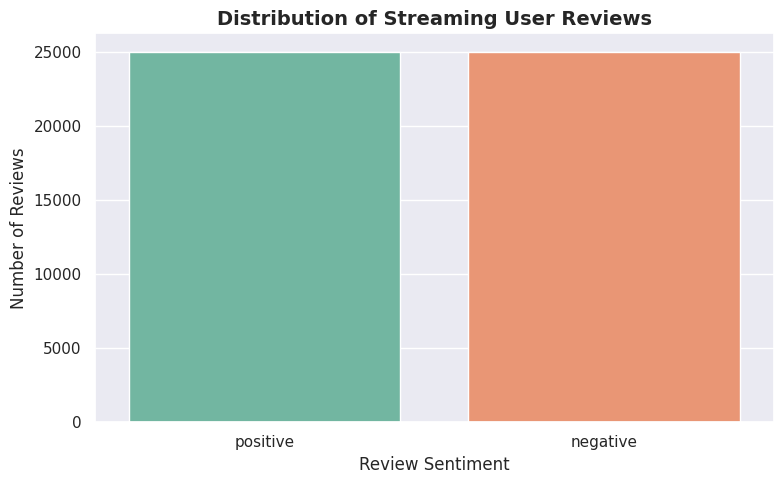

In [6]:
# Set up the canvas size
plt.figure(figsize=(8, 5))

# Create a bar chart of the sentiments
sns.countplot(data=df, x='sentiment', palette='Set2')

# Add professional titles and labels
plt.title('Distribution of Streaming User Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Review Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Display the chart cleanly
plt.tight_layout()
plt.show()

### 🧹 NLP Preprocessing: Text Cleaning & Standardization
Raw human text scraped from the internet is filled with "noise" that provides zero predictive value to a machine learning model.

* **Business Insight:** To ensure our algorithm focuses purely on the emotional vocabulary, we must build a text-cleaning pipeline. This pipeline will strip out leftover HTML tags, remove all punctuation, and standardize every word to lowercase. This prevents the algorithm from treating "Amazing!" and "amazing" as two completely separate variables.

In [7]:
import re

# 1. Define our text cleaning function
def clean_text(text):
    # Remove HTML tags (like <br />)
    text = re.sub(r'<.*?>', ' ', text)
    # Remove all punctuation and numbers (keep only letters)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Convert everything to lowercase
    text = text.lower()
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

print("Scrubbing 50,000 reviews... Please wait...")

# 2. Apply the scrubber to our dataset
df['clean_review'] = df['review'].apply(clean_text)

print("Text cleaning complete! Here is the before and after:")

# 3. Prove it worked by showing the old text next to the new clean text
display(df[['review', 'clean_review']].head())

Scrubbing 50,000 reviews... Please wait...
Text cleaning complete! Here is the before and after:


,review,clean_review
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with...
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomfortin...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",i thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air conditioned theater and watching a light hearted c...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />Thi...,basically there s a family where a little boy jake thinks there s a zombie in his closet his parents are fighting all the time this movie is slowe...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. Thi...",petter mattei s love in the time of money is a visually stunning film to watch mr mattei offers us a vivid portrait about human relations this is ...


### ☁️ Visualizing the Vocabulary: Word Clouds
With our text fully standardized, we can extract the most frequent vocabulary used by the audience.

* **Business Insight:** By separating the dataset by sentiment and generating Word Clouds, we can instantly identify the driving keywords behind audience satisfaction and dissatisfaction. (Note: We apply a 'Stopwords' filter to remove generic English words like 'the' and 'and', as well as generic industry terms like 'movie' or 'film', ensuring only the emotional and descriptive vocabulary remains).

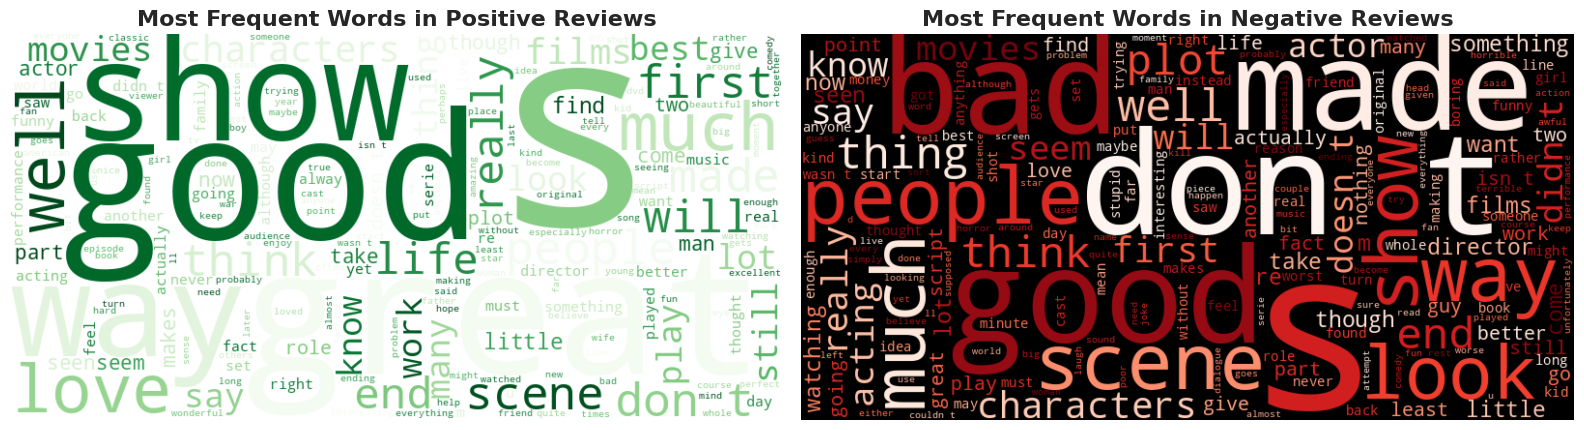

In [8]:
from wordcloud import WordCloud, STOPWORDS

# 1. Separate the text by sentiment
positive_text = ' '.join(df[df['sentiment'] == 'positive']['clean_review'])
negative_text = ' '.join(df[df['sentiment'] == 'negative']['clean_review'])

# 2. Configure the WordCloud engine
stopwords = set(STOPWORDS)
# Add generic movie terms to the filter so we only see descriptive words
stopwords.update(['movie', 'film', 'one', 'make', 'even', 'see', 'time', 'watch', 'character', 'story'])

# 3. Generate the clouds
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens', stopwords=stopwords).generate(positive_text)
wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds', stopwords=stopwords).generate(negative_text)

# 4. Plot them side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Positive Cloud
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Most Frequent Words in Positive Reviews', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Negative Cloud
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Most Frequent Words in Negative Reviews', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 🧮 Text-to-Math Vectorization & Machine Learning
Machine learning algorithms cannot interpret raw text. Before training our sentiment classifier, we must convert the English vocabulary into a mathematical matrix.

* **Business Insight:** We utilize a **TF-IDF Vectorizer** (Term Frequency-Inverse Document Frequency) to translate our reviews into numbers. This algorithm assigns a mathematical weight to every word. Once the text is vectorized, we train a **Logistic Regression** model to calculate the probability that a specific combination of words equates to a positive or negative sentiment.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(df['clean_review'], df['sentiment'], test_size=0.2, random_state=42)

# 2. Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

print("Converting 50,000 reviews into mathematical vectors...")
# Fit and transform the training text, but ONLY transform the test text
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 3. Build and Train the Logistic Regression Model
print("Training the Classification Engine...")
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_vec, y_train)

# 4. Make predictions on the hidden testing data
predictions = model.predict(X_test_vec)

# 5. Evaluate the results
print(f"\n🎯 NLP Sentiment Engine Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%\n")

Converting 50,000 reviews into mathematical vectors...
Training the Classification Engine...

🎯 NLP Sentiment Engine Accuracy: 89.49%



### 🔮 Live Engine Testing
To validate the robustness of our NLP pipeline, we will deploy a live testing function. This function takes a brand new, raw text string, pushes it through our custom cleaning scrubber, vectorizes it using the trained TF-IDF matrix, and outputs the Logistic Regression model's predicted sentiment.

In [10]:
# 1. Define the live prediction function
def predict_sentiment(custom_text):
    # Step A: Clean the raw text using our scrubber function
    cleaned = clean_text(custom_text)
    # Step B: Convert the cleaned text to math
    vectorized = vectorizer.transform([cleaned])
    # Step C: Make the prediction
    prediction = model.predict(vectorized)
    return prediction[0].upper()

# 2. Create two brand new, unseen reviews
review_1 = "I absolutely loved this! The acting was brilliant and the story kept me hooked the entire time. Highly recommend."
review_2 = "What a complete waste of time. The plot made no sense, the characters were boring, and the ending was terrible."

# 3. Test the engine
print("--- Live NLP Sentiment Predictions ---")
print(f"Test Review 1: {predict_sentiment(review_1)}")
print(f"Test Review 2: {predict_sentiment(review_2)}")

--- Live NLP Sentiment Predictions ---
Test Review 1: POSITIVE
Test Review 2: NEGATIVE
